
N_R1s(r) =
+22.1233 * exp(-9.9051 r)
+13.0077 * exp(-5.7429 r)
-10.7903 * r^2 * exp(-17.9816 r)
+47.9062 * r * exp(-8.3087 r)
+0.0247 * r * exp(-2.7611 r)
+0.0011 * r * exp(-1.8223 r)
+0.0002 * r * exp(-1.4191 r)

N_R2s(r) =
-4.2083 * exp(-9.9051 r)
+11.9497 * exp(-5.7429 r)
-3.2745 * r^2 * exp(-17.9816 r)
-18.4580 * r * exp(-8.3087 r)
-5.4726 * r * exp(-2.7611 r)
-2.7060 * r * exp(-1.8223 r)
-0.5755 * r * exp(-1.4191 r)

N_R2p(r) =
+1.4705 * r * exp(-8.3490 r)
+2.8448 * r * exp(-3.8827 r)
+3.2492 * r * exp(-2.5920 r)
+1.8059 * r * exp(-1.6946 r)
+0.5515 * r * exp(-1.1914 r)


/tmp/ipykernel_10732/61097867.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)



Saved: Nitrogen_HF_Compton_profile.csv


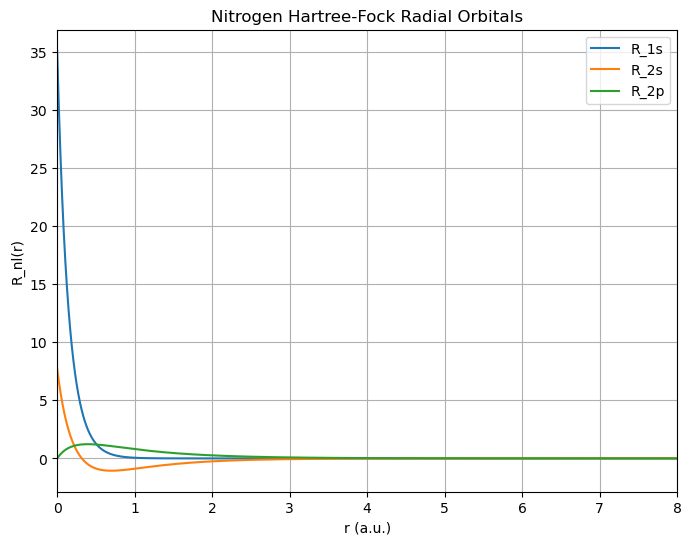

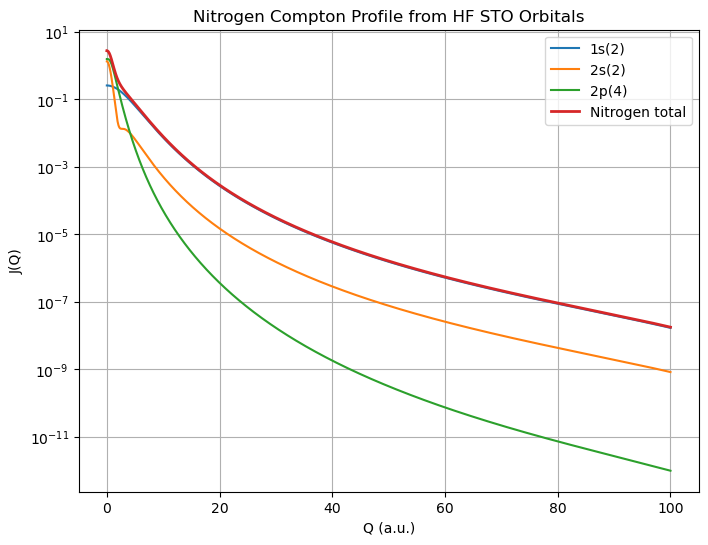

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Nitrogen Hartree-Fock STO data
# N: 1s(2) 2s(2) 2p(3)
# Format: (n_j, Z_j, C_j)
# =====================================================

nitrogen_1s = [
    (1,  9.9051,  0.354839),
    (1,  5.7429,  0.472579),
    (3, 17.9816, -0.001038),
    (2,  8.3087,  0.208492),
    (2,  2.7611,  0.001687),
    (2,  1.8223,  0.000206),
    (2,  1.4191,  0.000064),
]

nitrogen_2s = [
    (1,  9.9051, -0.067498),
    (1,  5.7429,  0.434142),
    (3, 17.9816, -0.000315),
    (2,  8.3087, -0.080331),
    (2,  2.7611, -0.374128),
    (2,  1.8223, -0.522775),
    (2,  1.4191, -0.207735),
]

nitrogen_2p = [
    (2, 8.3490, 0.006323),
    (2, 3.8827, 0.082938),
    (2, 2.5920, 0.260147),
    (2, 1.6946, 0.418361),
    (2, 1.1914, 0.308272),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================

def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R

# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 120.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build nitrogen radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, nitrogen_1s)
R2s = R_nl(r, nitrogen_2s)
R2p = R_nl(r, nitrogen_2p)

print_R_formula(nitrogen_1s, "N_R1s")
print_R_formula(nitrogen_2s, "N_R2s")
print_R_formula(nitrogen_2p, "N_R2p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================

I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)

# Nitrogen has 1s(2) 2s(2) 2p(3)
J_total = 2*J_1s + 2*J_2s + 3*J_2p
# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_2p_one_electron": J_2p,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(3)": 3*J_2p,
    "J_total_nitrogen": J_total
})

table.to_csv("Nitrogen_HF_Compton_profile.csv", index=False)
print("\nSaved: Nitrogen_HF_Compton_profile.csv")

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.xlim(0, 8)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Nitrogen Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 4*J_2p, label="2p(4)")
plt.plot(Q, J_total, label="Nitrogen total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Nitrogen Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()